# Introduction to Data Analysis

In this section, we import essential libraries that will help us explore and analyze the dataset.
- `pandas` for data manipulation.
- `matplotlib` & `seaborn` for data visualization.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Let's load the **120 Years of Olympic History - Athletes and Results** dataset. Since it's stored online, we use `pd.read_csv()` to read it directly from the URL.

In [3]:
url = "https://raw.githubusercontent.com/cstorm125/information_value/refs/heads/master/data/120-years-of-olympic-history-athletes-and-results/athlete_events.csv"
df = pd.read_csv(url)

Understanding the structure of the dataset is key before diving into analysis. Let's:
- Check the data types of each column.
- Count non-null values.
- Look at the first few rows.

In [18]:
print("Dataset Overview:")
print(df.info())
print("\nFirst 5 rows:")
print(df.head())

Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  object 
 2   Sex     271116 non-null  object 
 3   Age     261642 non-null  float64
 4   Height  210945 non-null  float64
 5   Weight  208241 non-null  float64
 6   Team    271116 non-null  object 
 7   NOC     271116 non-null  object 
 8   Games   271116 non-null  object 
 9   Year    271116 non-null  int64  
 10  Season  271116 non-null  object 
 11  City    271116 non-null  object 
 12  Sport   271116 non-null  object 
 13  Event   271116 non-null  object 
 14  Medal   39783 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 31.0+ MB
None

First 5 rows:
   ID                      Name Sex   Age  Height  Weight            Team  \
0   1                 A Dijiang   M  24.0   180.0    80.0       

A quick glance at summary statistics helps us understand numerical distributions, potential outliers, and missing values.

In [9]:
print("\nSummary Statistics:")
print(df.describe())
print("\nMissing Values:")
print(df.isnull().sum())


Summary Statistics:
                  ID            Age         Height         Weight  \
count  271116.000000  261642.000000  210945.000000  208241.000000   
mean    68248.954396      25.556898     175.338970      70.702393   
std     39022.286345       6.393561      10.518462      14.348020   
min         1.000000      10.000000     127.000000      25.000000   
25%     34643.000000      21.000000     168.000000      60.000000   
50%     68205.000000      24.000000     175.000000      70.000000   
75%    102097.250000      28.000000     183.000000      79.000000   
max    135571.000000      97.000000     226.000000     214.000000   

                Year  
count  271116.000000  
mean     1978.378480  
std        29.877632  
min      1896.000000  
25%      1960.000000  
50%      1988.000000  
75%      2002.000000  
max      2016.000000  

Missing Values:
ID             0
Name           0
Sex            0
Age         9474
Height     60171
Weight     62875
Team           0
NOC           

Missing values can affect our analysis. Here, we handle missing values in the 'Height' and 'Weight' columns by filling them with the median values.

In [10]:
df['Height'] = df['Height'].fillna(df['Height'].median())
df['Weight'] = df['Weight'].fillna(df['Weight'].median())

Grouping and counting occurrences of sports helps us understand which events are most frequent in the dataset.

In [11]:
print("\nTop 5 Most Frequent Sports:")
print(df['Sport'].value_counts().head(5))


Top 5 Most Frequent Sports:
Sport
Athletics     38624
Gymnastics    26707
Swimming      23195
Shooting      11448
Cycling       10859
Name: count, dtype: int64


A histogram is a great way to visualize the distribution of ages among Olympic athletes.

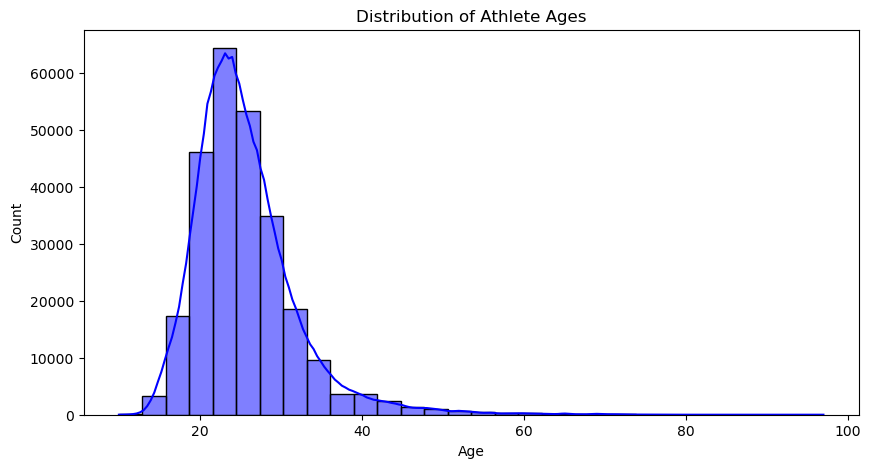

In [12]:
plt.figure(figsize=(10,5))
sns.histplot(df['Age'].dropna(), bins=30, kde=True, color='blue')
plt.title('Distribution of Athlete Ages')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

By grouping the data by `Sport` and computing the mean age, we can determine the age distribution across different sports.

In [13]:
sport_ages = df.groupby('Sport')['Age'].mean().sort_values(ascending=False)
print("\nTop 5 Sports by Average Athlete Age:")
print(sport_ages.head(5))


Top 5 Sports by Average Athlete Age:
Sport
Roque               53.333333
Art Competitions    45.901009
Alpinism            38.812500
Polo                35.333333
Equestrianism       34.390831
Name: Age, dtype: float64


A bar chart is useful for comparing the average ages of athletes in different sports.

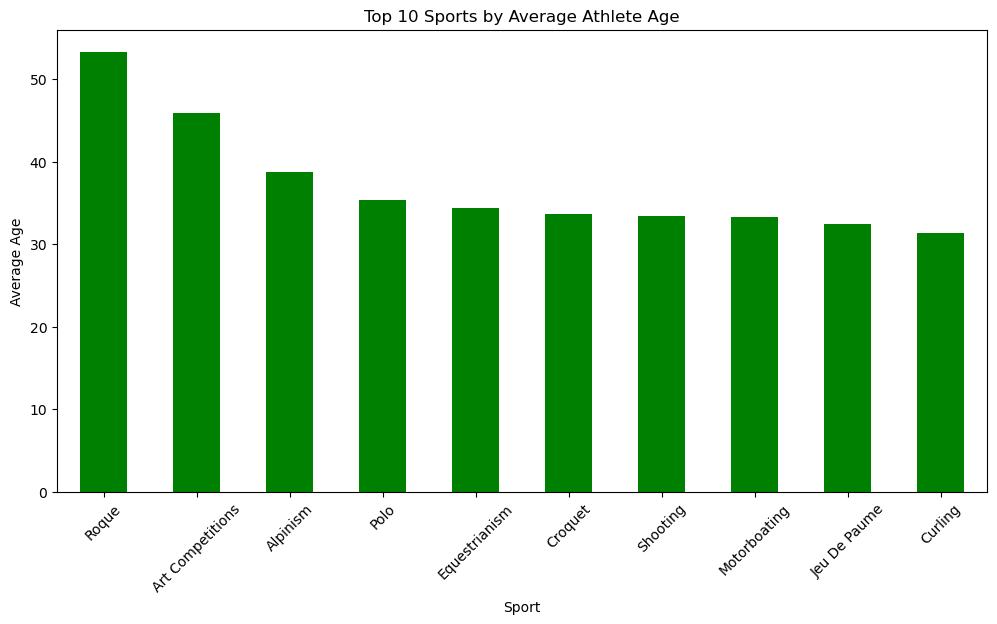

In [14]:
plt.figure(figsize=(12,6))
sport_ages.head(10).plot(kind='bar', color='green')
plt.title('Top 10 Sports by Average Athlete Age')
plt.xlabel('Sport')
plt.ylabel('Average Age')
plt.xticks(rotation=45)
plt.show()

Some data analysis made on the dataset especially for the country of Romania, which has a rich history in the Olympics. We will explore:
- The total number of medals won by Romania.
- The years when Romania won the most medals.
- The most decorated Romanian athletes.
- Visualizations to illustrate these findings.


Romania Medals by Year:
Year
1900      0
1924     16
1928      0
1932      0
1936      1
1948      0
1952      4
1956     19
1960     15
1964     16
1968     23
1972     40
1976     55
1980     68
1984    106
1988     58
1992     53
1994      0
1996     38
1998      0
2000     46
2002      0
2004     39
2006      0
2008     22
2010      0
2012     16
2014      0
2016     16
Name: Medal, dtype: int64


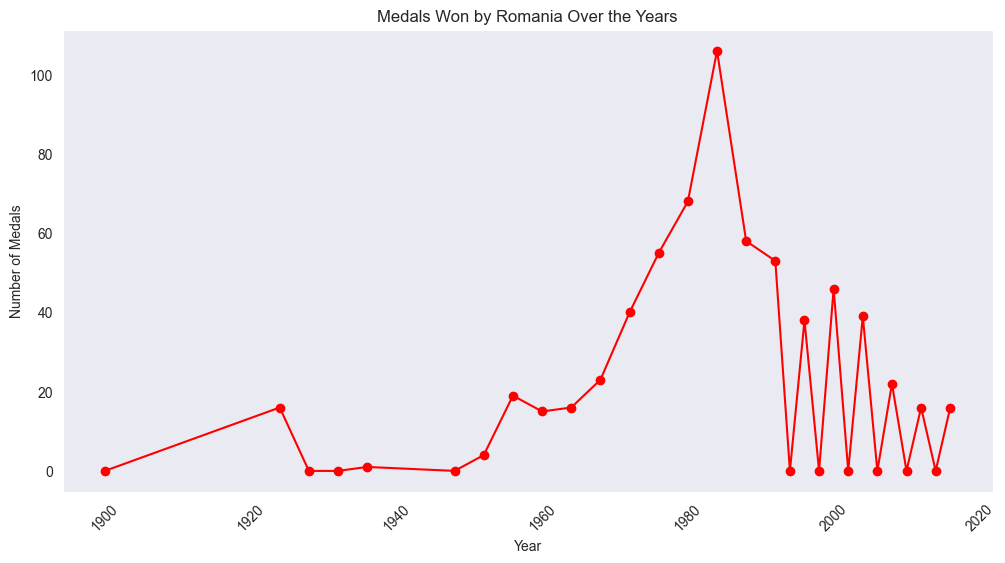

In [5]:
#when romania had the most medals
romania_medals = df[df['Team'] == 'Romania'].groupby('Year')['Medal'].count()
print("\nRomania Medals by Year:")
print(romania_medals)

#plot the medals won by romania over the years
plt.figure(figsize=(12,6))
romania_medals.plot(kind='line', marker='o', color='red')
plt.title('Medals Won by Romania Over the Years')
plt.xlabel('Year')
plt.ylabel('Number of Medals')
plt.xticks(rotation=45)
plt.grid()
plt.show()



Top 5 Most Decorated Romanian Athletes:
Name
Nadia Elena Comneci (-Conner)          9
Elisabeta Oleniuc-Lip                  8
Ivan Patzaichin                        7
Simona Amnar (-Tabr)                   7
Lavinia Corina Miloovici               6
Doina Ignat                            6
Veronica Cogeanu-Cochela               6
Viorica Daniela Siliva (-Harper)       6
Georgeta Damian-Andrunache             6
Gina Elena Gogean (-Groza)             5
Elena Georgescu-Nedelcu                5
Constana Pipot-Burcic                  5
Ecaterina (Katalin-) Szabo (-Tamas)    5
Ctlina Ponor                           5
Viorica Susanu                         5
Doina Liliana Snep-Blan                4
Marius Daniel Urzic                    4
Rodica Arba-Pucatu                     4
Sandra Raluca Izbaa                    4
Dimitrie Popescu                       4
Name: Medal, dtype: int64

Nadia in the Olympics:
                                Name       Sport   Medal
43773  Nadia Elena Comneci 

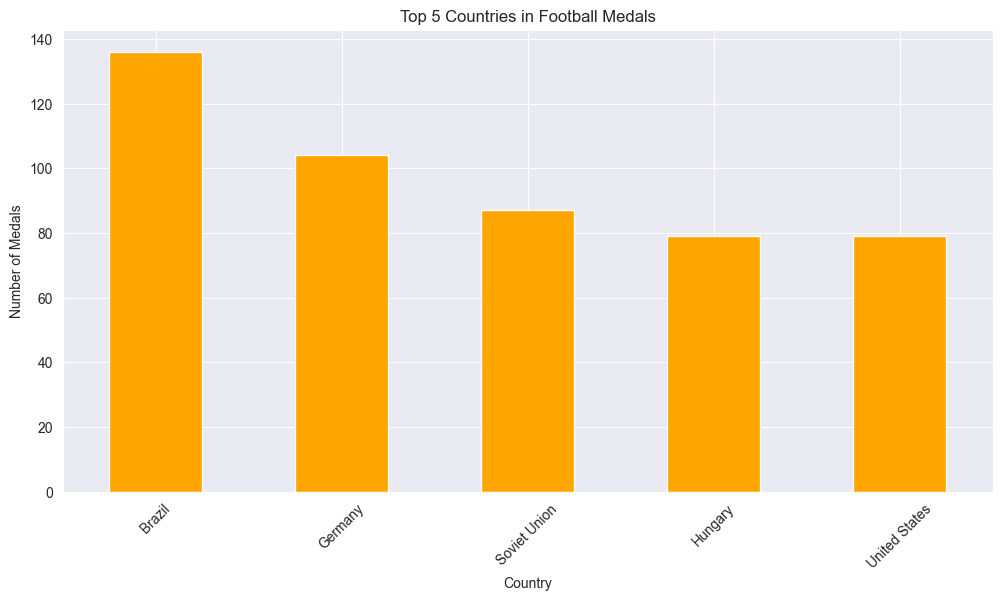

In [29]:
#who are the most 5 decorated athletes in the olympics for romania
romania_athletes = df[df['Team'] == 'Romania'].groupby('Name')['Medal'].count().sort_values(ascending=False)
print("\nTop 5 Most Decorated Romanian Athletes:")
print(romania_athletes.head(20))

#check if name contains "Nadia" 
nadia = df[df['Name'].str.contains('Nadia', case=False) & (df['Team'] == 'Romania')]
print("\nNadia in the Olympics:")
print(nadia[['Name', 'Sport', 'Medal']])  


lebron = df[df['Name'].str.contains('LeBron', case=False) & (df['Team'] == 'United States') & (df['Sport'] == 'Basketball')]
print("\nLeBron in the Olympics:")
print(lebron[['Name', 'Sport', 'Medal']])


#find and plot the top 5 countries that won the most medals in football
football_medals = df[df['Sport'] == 'Football'].groupby('Team')['Medal'].count().sort_values(ascending=False)
print("\nTop 5 Countries in Football Medals:")
print(football_medals.head(20))
plt.figure(figsize=(12,6))
football_medals.head(5).plot(kind='bar', color='orange')
plt.title('Top 5 Countries in Football Medals')
plt.xlabel('Country')
plt.ylabel('Number of Medals')
plt.xticks(rotation=45)
plt.show()


Top Country in Curling Medals (2000-2020):
Team
Canada    38
Name: Medal, dtype: int64


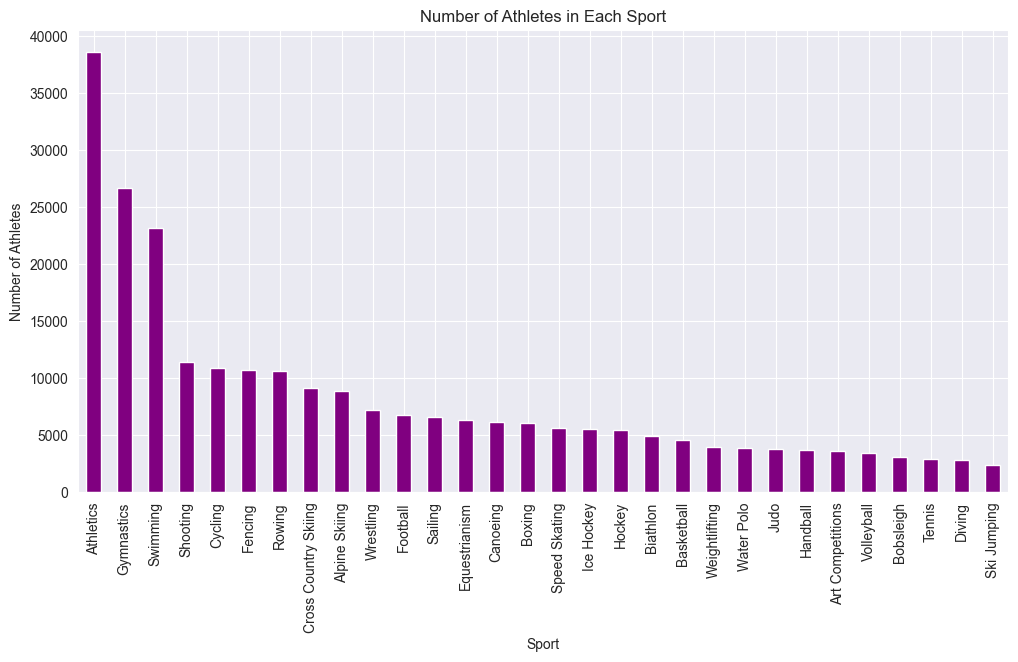

Year
1924    0
1952    0
1964    0
Name: Medal, dtype: int64

Romania Medals in Winter Olympics by Year:
Year
1932    0
1936    0
1948    0
1952    0
1956    0
1964    0
1968    0
1972    0
1976    0
1980    0
1984    0
1988    0
1992    0
1994    0
1998    0
2002    0
2006    0
2010    0
2014    0
Name: Medal, dtype: int64


In [20]:
#find the country with most medals in curling from 2000 to 2020
curling = df[(df['Sport'] == 'Curling') & (df['Year'] >= 2000)]
medals = curling.groupby('Team')['Medal'].count().sort_values(ascending=False)
print("\nTop Country in Curling Medals (2000-2020):")
print(medals.head(1))

#plot all the sports from the olympics and the number of athletes in each sport and plot it
sport_counts = df['Sport'].value_counts().head(30)
plt.figure(figsize=(12,6))
sport_counts.plot(kind='bar', color='purple')
plt.title('Number of Athletes in Each Sport')
plt.xlabel('Sport')
plt.ylabel('Number of Athletes')
plt.xticks(rotation=90)
plt.show()

#plot the romania in the olympics at basketball
basketball = df[(df['Sport'] == 'Football') & (df['Team'] == 'Romania')]
print(basketball.groupby('Year')['Medal'].count())


medalWinter = df[(df['Season'] == 'Winter') & (df['Team'] == 'Romania')].groupby('Year')['Medal'].count()
print("\nRomania Medals in Winter Olympics by Year:")
print(medalWinter)

In [ ]:
#find all the team sports in which romania has won medals and the number of players in each sport
